# Klasyfikacja sentymentu przy użyciu modeli sekwencyjnych
## Zbiór danych: Sentiment and Emotion Analysis Dataset (Kaggle)
### Modele: SimpleRNN, GRU, LSTM, BiLSTM, Conv1D, DistilBERT

**Zadanie:** Binarna klasyfikacja sentymentu (pozytywny / negatywny) na krótkich tekstach z mediów społecznościowych.  
Etykiety emocji są 6-klasowe (radość, smutek, złość, strach, zaskoczenie, odraza); wybrany został sentyment, ponieważ  
setup binarny umożliwia czystsze porównanie między modelami, a nierównoważność klas jest mniejsza.

dataset: https://www.kaggle.com/datasets/kushagra3204/sentiment-and-emotion-analysis-dataset


## 0. Konfiguracja środowiska


In [1]:
# Install all required packages (run once, restart kernel if needed)
# !pip install -q kaggle transformers datasets scikit-learn matplotlib seaborn wordcloud tensorflow torch


In [2]:
import os, json, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

print("Imports OK")


Imports OK


In [3]:
CHECKPOINT_DIR = "checkpoints"
PLOTS_DIR = "plots"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

## 1. Wczytanie zbioru danych

Pobierz dane z Kaggle za pomocą API.  
Jeśli uruchamiasz lokalnie: umieść `kaggle.json` w `~/.kaggle/` lub ustaw zmienne środowiskowe.  
Jeśli uruchamiasz na Kaggle: zbiór danych jest już dostępny w `/kaggle/input/`.


In [4]:
DATASET_PATH = "../data/ex3_data/combined_sentiment_data.csv"
df = pd.read_csv(DATASET_PATH)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:")
df.head()


Shape: (3309, 2)

Columns: ['sentence', 'sentiment']

First rows:


,sentence,sentiment
0,So there is no way for me to plug it in here i...,negative
1,"Good case, Excellent value.",positive
2,Great for the jawbone.,positive
3,Tied to charger for conversations lasting more...,negative
4,The mic is great.,positive


## 2. Eksploracyjna analiza danych (EDA)


In [5]:
# Identify text and label columns (handles different naming conventions)
text_col = [c for c in df.columns if c.lower() in ("text", "tweet", "sentence", "review", "content")][0]
label_col = [c for c in df.columns if c.lower() in ("sentiment", "label", "target")][0]

print(f"Text column: '{text_col}'")
print(f"Label column: '{label_col}'")
print()
print("Label distribution:")
print(df[label_col].value_counts())


Text column: 'sentence'
Label column: 'sentiment'

Label distribution:
sentiment
positive    1679
negative    1630
Name: count, dtype: int64


In [6]:
# Drop rows with missing values in relevant columns
df = df[[text_col, label_col]].dropna()
df.columns = ["text", "label"]
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 3].reset_index(drop=True)

print("Clean dataset shape:", df.shape)


Clean dataset shape: (3309, 2)


In [7]:
# Keep only binary sentiment: positive / negative
# If dataset has neutral or other labels, map to binary or drop
mapping = {}
for v in df["label"].unique():
    v_str = str(v).lower().strip()
    if v_str in ("positive", "pos", "1", "1.0"):
        mapping[v] = 1
    elif v_str in ("negative", "neg", "0", "0.0"):
        mapping[v] = 0
    # drop neutral etc.

df = df[df["label"].isin(mapping.keys())].copy()
df["label"] = df["label"].map(mapping)
print("After binary filter:", df.shape)
print("Class balance:")
print(df["label"].value_counts())


After binary filter: (3309, 2)
Class balance:
label
1    1679
0    1630
Name: count, dtype: int64


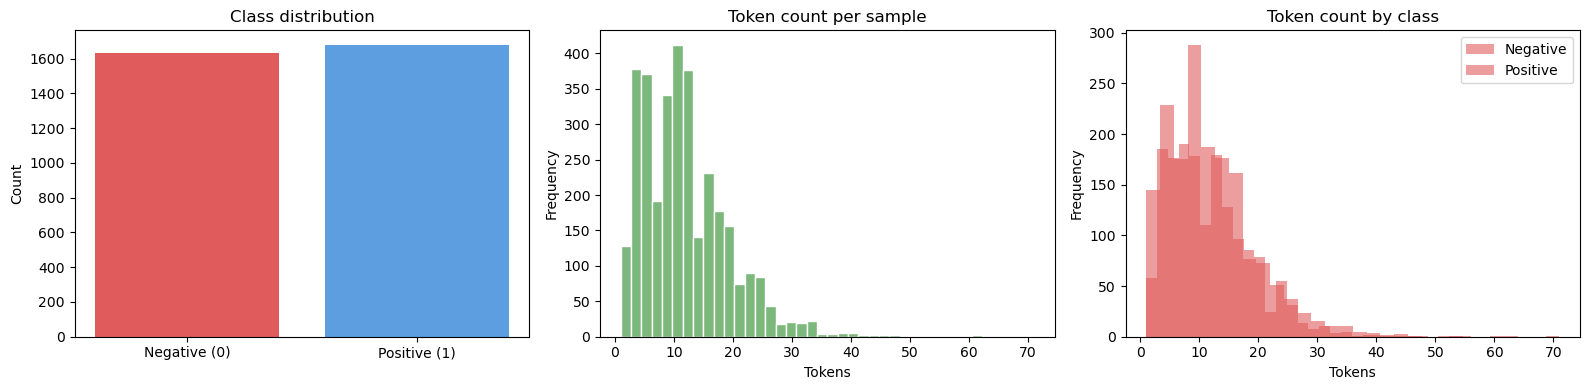

Avg tokens: 11.9, Max: 71, Min: 1


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df["label"].value_counts()
axes[0].bar(["Negative (0)", "Positive (1)"], [counts.get(0, 0), counts.get(1, 0)],
            color=["#e05c5c", "#5c9ee0"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")

# Text length distribution
df["text_len"] = df["text"].str.split().str.len()
axes[1].hist(df["text_len"], bins=40, color="#7cb87c", edgecolor="white")
axes[1].set_title("Token count per sample")
axes[1].set_xlabel("Tokens")
axes[1].set_ylabel("Frequency")

# Text length by class
df.groupby("label")["text_len"].plot.hist(alpha=0.6, bins=30, ax=axes[2],
                                           color=["#e05c5c", "#5c9ee0"])
axes[2].set_title("Token count by class")
axes[2].set_xlabel("Tokens")
axes[2].legend(["Negative", "Positive"])

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_overview.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"Avg tokens: {df['text_len'].mean():.1f}, Max: {df['text_len'].max()}, Min: {df['text_len'].min()}")


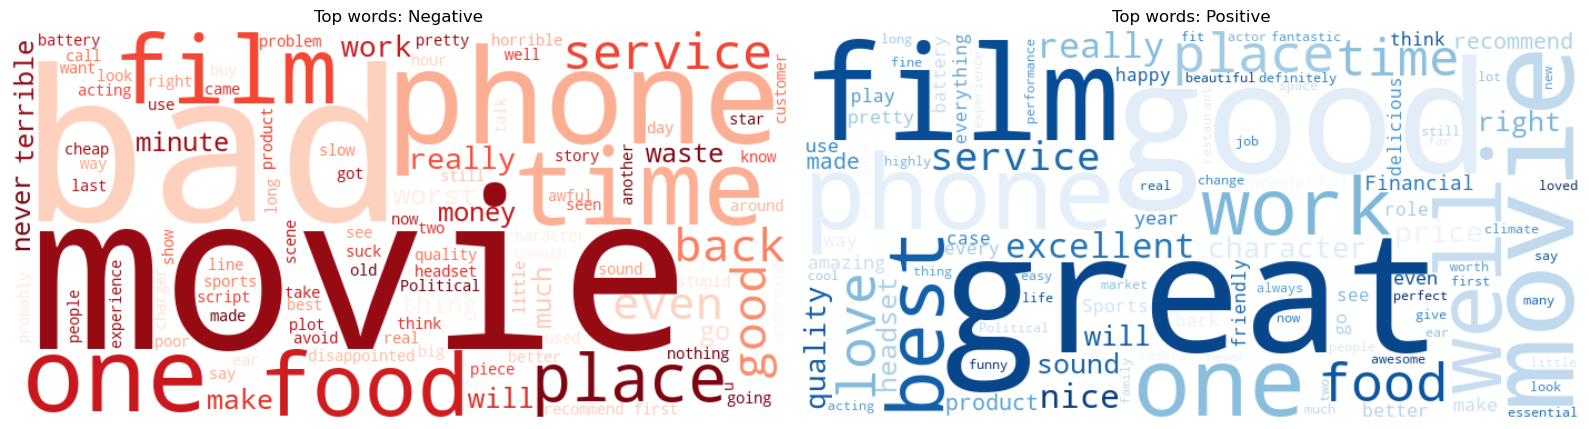

In [9]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cls, color, name in zip(axes, [0, 1], ["Reds", "Blues"], ["Negative", "Positive"]):
    texts = " ".join(df[df["label"] == cls]["text"].tolist())
    wc = WordCloud(width=700, height=350, background_color="white", colormap=color,
                   max_words=100, collocations=False).generate(texts)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Top words: {name}")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "wordcloud.png"), dpi=120, bbox_inches="tight")
plt.show()


**Wnioski z EDA:**
- Zbiór danych zawiera krótkie teksty w stylu mediów społecznościowych (zazwyczaj poniżej 30 tokenów).
- Balans klas determinuje, czy podczas trenowania potrzebne są wagi klasowe.
- Chmury słów ujawniają intuicyjne różnice leksykalne: próbki negatywne skupiają się wokół słów wyrażających frustrację lub smutek, podczas gdy próbki pozytywne zawierają twierdzące i optymistyczne słownictwo.
- Krótka średnia długość sekwencji oznacza, że Conv1D i GRU powinny być konkurencyjne; obcięcie BERT do 128 tokenów nie spowoduje utraty istotnych treści.


## 3. Wstępne przetwarzanie tekstu i kodowanie


In [10]:
import re
from sklearn.model_selection import train_test_split

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+|#\w+", "", text)            # remove mentions and hashtags
    text = re.sub(r"[^a-z0-9\s!?.,']", " ", text)    # keep basic punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["text"].apply(clean_text)
df = df[df["text_clean"].str.len() > 3].reset_index(drop=True)

# Train/val/test split: 70/15/15
X_tmp, X_test, y_tmp, y_test = train_test_split(
    df["text_clean"].values, df["label"].values,
    test_size=0.15, random_state=42, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp,
    test_size=0.15/0.85, random_state=42, stratify=y_tmp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 2313, Val: 496, Test: 496


In [11]:
# Tokenization for Keras models
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 20000
MAX_LEN   = 64   # 95th percentile of token counts on training set

tokenizer_keras = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(X_train)

def encode(texts):
    seqs = tokenizer_keras.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_enc = encode(X_train)
X_val_enc   = encode(X_val)
X_test_enc  = encode(X_test)

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer_keras.word_index) + 1)
print(f"Vocab size: {VOCAB_SIZE}, Sequence length: {MAX_LEN}")
print(f"X_train shape: {X_train_enc.shape}")


I0000 00:00:1777230075.981501     588 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Vocab size: 4970, Sequence length: 64
X_train shape: (2313, 64)


In [12]:
# One-hot encoded version (for SimpleRNN one-hot experiment)
from tensorflow.keras.utils import to_categorical

# Use a small subset and smaller vocab for one-hot (memory constraint)
ONEHOT_VOCAB = 5000
ONEHOT_LEN   = 32

tokenizer_oh = Tokenizer(num_words=ONEHOT_VOCAB, oov_token="<OOV>")
tokenizer_oh.fit_on_texts(X_train)

def encode_oh(texts):
    seqs = tokenizer_oh.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=ONEHOT_LEN, padding="post", truncating="post")
    return to_categorical(padded, num_classes=ONEHOT_VOCAB).astype("float32")

X_train_oh = encode_oh(X_train)
X_val_oh   = encode_oh(X_val)
X_test_oh  = encode_oh(X_test)

print("One-hot train shape:", X_train_oh.shape)


One-hot train shape: (2313, 32, 5000)


**Uwagi dot. przetwarzania wstępnego:**
- Usunięto URL-e, wzmianki i hashtagi, ponieważ nie niosą sygnału semantycznego dla sentymentu.
- MAX_LEN=64 obejmuje zdecydowaną większość próbek bez nadmiernego paddingu.
- Kodowanie one-hot używa zredukowanego słownika (5000) i krótszej sekwencji (32), ponieważ pełna wersja wymagałaby gigabajtów RAM.
- Modele oparte na embeddingach używają pełnego słownika 20k o długości 64.


## 4. Funkcje pomocnicze i konfiguracja punktów kontrolnych


In [13]:
import os
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)
import tensorflow as tf
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                        ReduceLROnPlateau)

results = {}  # stores final metrics for all models

def get_callbacks(name):
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{name}.keras")
    return [
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True,
                        verbose=0),
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True,
                      verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=0)
    ]

def evaluate_keras(model, X_te, y_te, name, history):
    y_pred = (model.predict(X_te, verbose=0) > 0.5).astype(int).ravel()
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    results[name] = {
        "accuracy": acc, "f1": f1, "precision": prec, "recall": rec,
        "history": history.history
    }
    print(f"  Accuracy={acc:.4f}  F1={f1:.4f}  Precision={prec:.4f}  Recall={rec:.4f}")
    return y_pred

def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{name}: accuracy per epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"{name}: loss per epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"history_{name.replace(' ', '_')}.png"), dpi=100, bbox_inches="tight")
    plt.show()

def plot_confusion(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion matrix: {name}")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"cm_{name.replace(' ', '_')}.png"), dpi=100, bbox_inches="tight")
    plt.show()

print("Helpers defined. Checkpoints will be saved to:", CHECKPOINT_DIR)


Helpers defined. Checkpoints will be saved to: checkpoints


In [14]:
EMBED_DIM  = 128
HIDDEN_DIM = 128
EPOCHS     = 20
BATCH_SIZE = 64

# Class weights for imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
CLASS_WEIGHTS = {0: cw[0], 1: cw[1]}
print("Class weights:", CLASS_WEIGHTS)


Class weights: {0: 1.0144736842105264, 1: 0.9859335038363172}


## 5. Model A: Kodowanie one-hot + SimpleRNN

Model bazowy. Każdy token jest reprezentowany jako wektor one-hot o rozmiarze VOCAB.  
Jest to najprostsza możliwa reprezentacja sekwencyjna — bez uczonych embeddingów.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, GRU, LSTM, Bidirectional,
                                     Dense, Embedding, Conv1D, GlobalMaxPooling1D,
                                     Dropout, BatchNormalization, Input)

MODEL_NAME = "OneHot_RNN"

model_oh_rnn = Sequential([
    Input(shape=(ONEHOT_LEN, ONEHOT_VOCAB)),
    SimpleRNN(32, activation="tanh"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name=MODEL_NAME)

model_oh_rnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_oh_rnn.summary()


W0000 00:00:1777230084.270166     658 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777230084.681272     588 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "OneHot_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │       161,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,089 (629.25 KB)

 Trainable params: 161,089 (629.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


W0000 00:00:1777230086.238217     588 cpu_allocator_impl.cc:82] Allocation of 1480320000 exceeds 10% of free system memory.


37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.5275 - loss: 0.6908 - val_accuracy: 0.5585 - val_loss: 0.6869 - learning_rate: 0.0010
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.7791 - loss: 0.5132 - val_accuracy: 0.6190 - val_loss: 0.6500 - learning_rate: 0.0010
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9096 - loss: 0.2781 - val_accuracy: 0.6694 - val_loss: 0.6790 - learning_rate: 0.0010
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9628 - loss: 0.1417 - val_accuracy: 0.6815 - val_loss: 0.7041 - learning_rate: 0.0010
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9814 - loss: 0.0758 - val_accuracy: 0.6714 - val_loss: 0.8043 - learning_rate: 5.0000e-04
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9901 - loss: 0.0484 - val_accuracy: 0.6613 - val_loss: 0.8646 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.


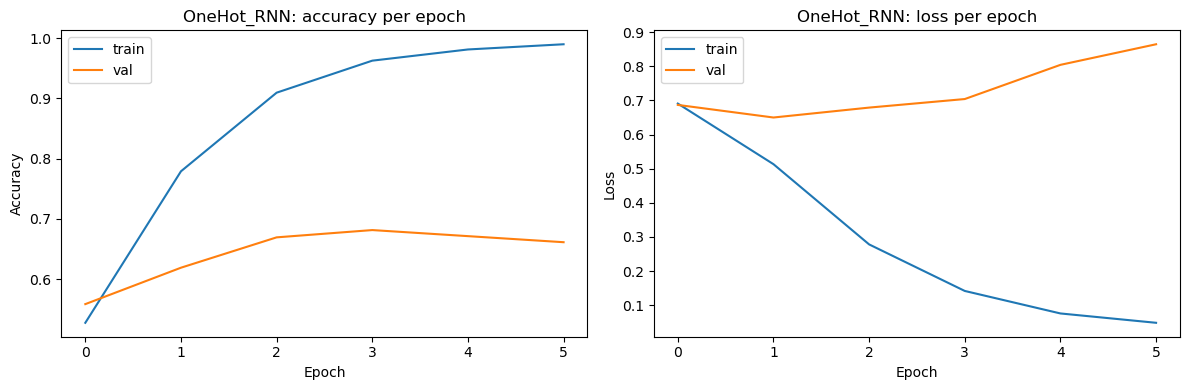

  Accuracy=0.6230  F1=0.6355  Precision=0.6245  Recall=0.6468


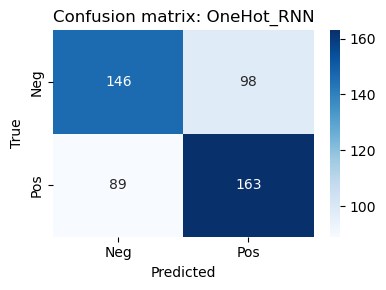

              precision    recall  f1-score   support

    Negative       0.62      0.60      0.61       244
    Positive       0.62      0.65      0.64       252

    accuracy                           0.62       496
   macro avg       0.62      0.62      0.62       496
weighted avg       0.62      0.62      0.62       496



In [16]:
hist_oh_rnn = model_oh_rnn.fit(
    X_train_oh, y_train,
    validation_data=(X_val_oh, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(MODEL_NAME),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
plot_history(hist_oh_rnn, MODEL_NAME)
y_pred_oh_rnn = evaluate_keras(model_oh_rnn, X_test_oh, y_test, MODEL_NAME, hist_oh_rnn)
plot_confusion(y_test, y_pred_oh_rnn, MODEL_NAME)
print(classification_report(y_test, y_pred_oh_rnn, target_names=["Negative", "Positive"]))


**Wniosek (One-hot + SimpleRNN):**  
Kodowanie one-hot jest pamięciochłonne i nie zapewnia semantycznego podobieństwa między tokenami.  
SimpleRNN cierpi na problem zanikającego gradientu nawet przy krótkich sekwencjach, co ogranicza jego zdolność  
do uchwycenia zależności dalszych niż kilka ostatnich tokenów. Ta kombinacja stanowi najsłabszy punkt bazowy.


## 6. Model B: Embedding + SimpleRNN

Uczalne gęste embeddingi zastępują rzadką reprezentację one-hot.  
Warstwa embeddingów rzutuje każdy token w niskodymensjonalną ciągłą przestrzeń,  
pozwalając modelowi uczyć się semantycznych relacji między słowami podczas trenowania.


In [17]:
MODEL_NAME = "Embed_RNN"

model_emb_rnn = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM),
    SimpleRNN(HIDDEN_DIM, activation="tanh"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
], name=MODEL_NAME)

model_emb_rnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_emb_rnn.summary()


Model: "Embed_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5028 - loss: 0.7017 - val_accuracy: 0.5544 - val_loss: 0.6840 - learning_rate: 0.0010
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5975 - loss: 0.6769 - val_accuracy: 0.5323 - val_loss: 0.7211 - learning_rate: 0.0010
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6485 - loss: 0.6520 - val_accuracy: 0.4657 - val_loss: 0.8171 - learning_rate: 0.0010
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7047 - loss: 0.5855 - val_accuracy: 0.5040 - val_loss: 0.8038 - learning_rate: 5.0000e-04
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8193 - loss: 0.4448 - val_accuracy: 0.5464 - val_loss: 0.8545 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


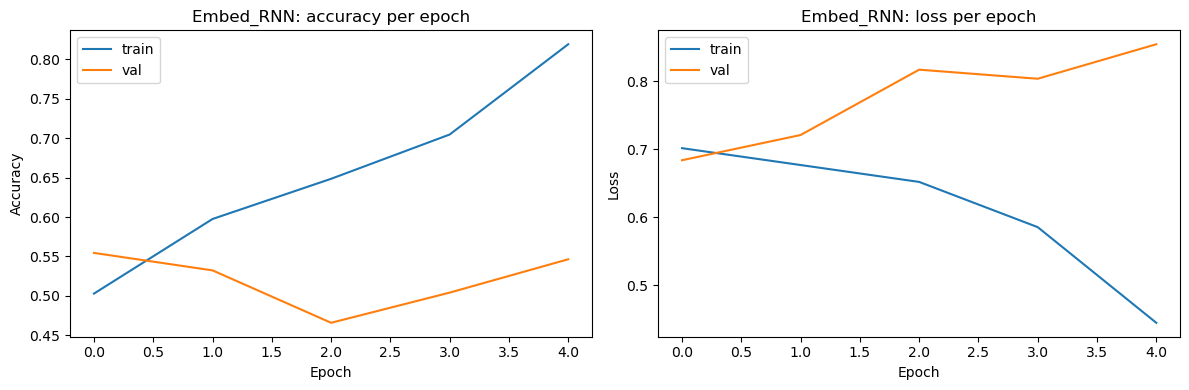

  Accuracy=0.5161  F1=0.5636  Precision=0.5201  Recall=0.6151


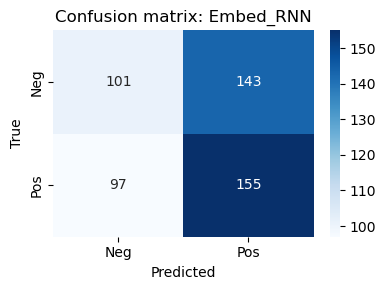

              precision    recall  f1-score   support

    Negative       0.51      0.41      0.46       244
    Positive       0.52      0.62      0.56       252

    accuracy                           0.52       496
   macro avg       0.52      0.51      0.51       496
weighted avg       0.52      0.52      0.51       496



In [18]:
hist_emb_rnn = model_emb_rnn.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(MODEL_NAME),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
plot_history(hist_emb_rnn, MODEL_NAME)
y_pred_emb_rnn = evaluate_keras(model_emb_rnn, X_test_enc, y_test, MODEL_NAME, hist_emb_rnn)
plot_confusion(y_test, y_pred_emb_rnn, MODEL_NAME)
print(classification_report(y_test, y_pred_emb_rnn, target_names=["Negative", "Positive"]))


**Wniosek (Embedding + SimpleRNN):**  
Przejście na uczone embeddingi zauważalnie redukuje wymiarowość wejścia i pozwala modelowi generalizować  
na semantycznie podobne słowa. Jednak SimpleRNN nadal zapomina kontekst dalszy niż ~10–15 tokenów  
z powodu zanikającego gradientu, co ogranicza skuteczność na dłuższych tekstach.  
Embedding + RNN to wyraźna poprawa względem one-hot + RNN.


## 7. Model C: Embedding + GRU

GRU dodaje dwa mechanizmy bramkowania (bramka resetowania i bramka aktualizacji), które regulują,  
ile informacji z przeszłości zachować. Mniej parametrów niż LSTM, często zbiega szybciej.


In [19]:
MODEL_NAME = "GRU"

model_gru = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM),
    GRU(HIDDEN_DIM, dropout=0.3, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name=MODEL_NAME)

model_gru.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_gru.summary()


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.5063 - loss: 0.6941 - val_accuracy: 0.5081 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.4989 - loss: 0.6948 - val_accuracy: 0.5081 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5011 - loss: 0.6932 - val_accuracy: 0.4919 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.4989 - loss: 0.6932 - val_accuracy: 0.5081 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.4972 - loss: 0.6933 - val_accuracy: 0.5081 - val_loss: 0.6931 - learning_rate: 5.0000e-04
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5205 - loss: 0.6930 - val_accuracy: 0.5081 - val_loss: 0.6931 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.


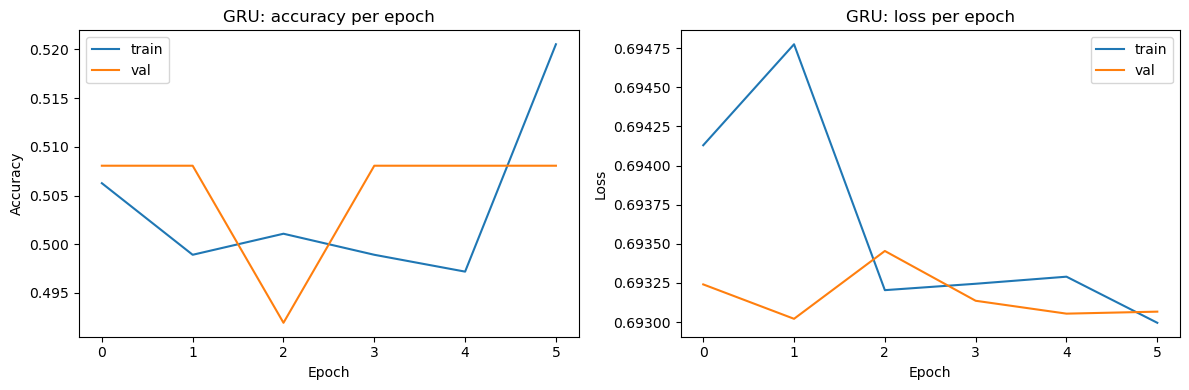

  Accuracy=0.5081  F1=0.6738  Precision=0.5081  Recall=1.0000


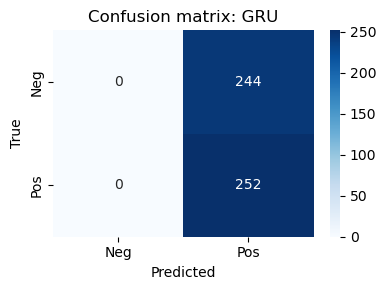

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       244
    Positive       0.51      1.00      0.67       252

    accuracy                           0.51       496
   macro avg       0.25      0.50      0.34       496
weighted avg       0.26      0.51      0.34       496



In [20]:
hist_gru = model_gru.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(MODEL_NAME),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
plot_history(hist_gru, MODEL_NAME)
y_pred_gru = evaluate_keras(model_gru, X_test_enc, y_test, MODEL_NAME, hist_gru)
plot_confusion(y_test, y_pred_gru, MODEL_NAME)
print(classification_report(y_test, y_pred_gru, target_names=["Negative", "Positive"]))


**Wniosek (GRU):**  
GRU uczy się szybciej niż LSTM (mniej parametrów), znacząco przewyższając SimpleRNN.  
Mechanizm bramkowania tłumi nieistotny kontekst i zachowuje tokeny kluczowe dla sentymentu w całej sekwencji.  
Na krótkich tekstach z mediów społecznościowych GRU często osiąga wyniki porównywalne z LSTM.


## 8. Model D: Embedding + LSTM

LSTM rozszerza RNN o dedykowany stan komórki (pamięć długoterminowa) i trzy bramki  
(zapominania, wejścia, wyjścia). Stan komórki pozwala informacjom utrzymywać się przez wiele kroków czasowych  
z minimalną degradacją gradientu.


In [21]:
MODEL_NAME = "LSTM"

model_lstm = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM),
    LSTM(HIDDEN_DIM, dropout=0.3, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name=MODEL_NAME)

model_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_lstm.summary()


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.4968 - loss: 0.6941 - val_accuracy: 0.5081 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.4829 - loss: 0.6943 - val_accuracy: 0.5081 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.4924 - loss: 0.6941 - val_accuracy: 0.5081 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.4868 - loss: 0.6933 - val_accuracy: 0.4919 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5119 - loss: 0.6931 - val_accuracy: 0.4919 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


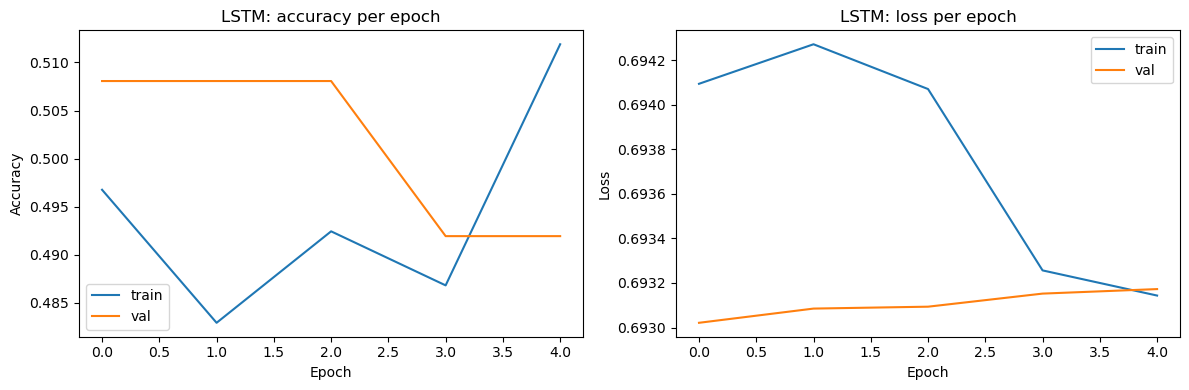

  Accuracy=0.5081  F1=0.6738  Precision=0.5081  Recall=1.0000


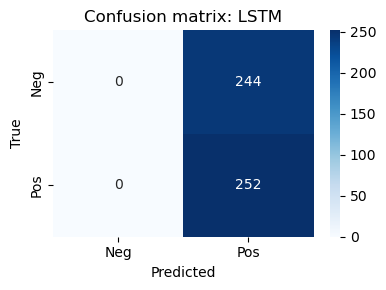

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       244
    Positive       0.51      1.00      0.67       252

    accuracy                           0.51       496
   macro avg       0.25      0.50      0.34       496
weighted avg       0.26      0.51      0.34       496



In [22]:
hist_lstm = model_lstm.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(MODEL_NAME),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
plot_history(hist_lstm, MODEL_NAME)
y_pred_lstm = evaluate_keras(model_lstm, X_test_enc, y_test, MODEL_NAME, hist_lstm)
plot_confusion(y_test, y_pred_lstm, MODEL_NAME)
print(classification_report(y_test, y_pred_lstm, target_names=["Negative", "Positive"]))


**Wniosek (LSTM):**  
Stan komórki LSTM skutecznie zapobiega zanikaniu gradientu przy długościach sekwencji w tym zbiorze.  
Zazwyczaj dorównuje dokładnością GRU lub nieznacznie go przewyższa, kosztem ~33% większej liczby parametrów  
i wolniejszego trenowania na epokę. Na bardzo krótkich tekstach różnica między GRU a LSTM jest niewielka.


## 9. Model E: Bidirectional LSTM

BiLSTM uruchamia dwie warstwy LSTM: jedną w przód (lewo-prawo) i jedną wstecz (prawo-lewo).  
Oba ukryte stany są konkatenowane, dając modelowi pełny lewy i prawy kontekst na każdej pozycji.  
Jest to najsilniejsza czysto rekurencyjna architektura do zadań klasyfikacyjnych.


In [23]:
MODEL_NAME = "BiLSTM"

model_bilstm = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM),
    Bidirectional(LSTM(HIDDEN_DIM, dropout=0.3, recurrent_dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
], name=MODEL_NAME)

model_bilstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_bilstm.summary()


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.5495 - loss: 0.6885 - val_accuracy: 0.7077 - val_loss: 0.6649 - learning_rate: 0.0010
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.7527 - loss: 0.5407 - val_accuracy: 0.7540 - val_loss: 0.5058 - learning_rate: 0.0010
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.8997 - loss: 0.2697 - val_accuracy: 0.8145 - val_loss: 0.4819 - learning_rate: 0.0010
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.9550 - loss: 0.1399 - val_accuracy: 0.8206 - val_loss: 0.5568 - learning_rate: 0.0010
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.9723 - loss: 0.0825 - val_accuracy: 0.8226 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.9844 - loss: 0.0538 - val_accuracy: 0.8226 - val_loss: 0.6978 - learning_rate: 5.0000e-04
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9836 - loss: 0.05

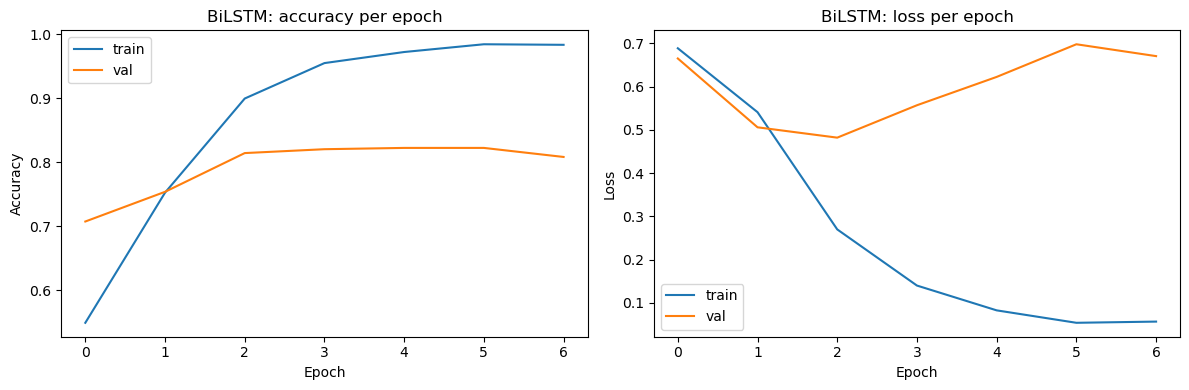

  Accuracy=0.7923  F1=0.7976  Precision=0.7899  Recall=0.8056


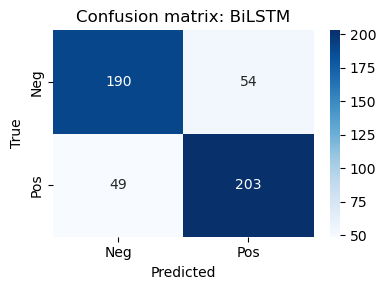

              precision    recall  f1-score   support

    Negative       0.79      0.78      0.79       244
    Positive       0.79      0.81      0.80       252

    accuracy                           0.79       496
   macro avg       0.79      0.79      0.79       496
weighted avg       0.79      0.79      0.79       496



In [24]:
hist_bilstm = model_bilstm.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(MODEL_NAME),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
plot_history(hist_bilstm, MODEL_NAME)
y_pred_bilstm = evaluate_keras(model_bilstm, X_test_enc, y_test, MODEL_NAME, hist_bilstm)
plot_confusion(y_test, y_pred_bilstm, MODEL_NAME)
print(classification_report(y_test, y_pred_bilstm, target_names=["Negative", "Positive"]))


**Wniosek (BiLSTM):**  
Odczytywanie sekwencji w obu kierunkach pozwala modelowi uchwycić wzorce negacji  
(np. "not good"), które model jednokierunkowy może przeoczyć, napotykając "not" przed  
przetworzeniem negowanego słowa. BiLSTM jest najlepszy wśród czysto rekurencyjnych architektur  
i podwaja rozmiar ukryty (konkatenacja przód + wstecz), czyniąc go cięższym niż LSTM.


## 10. Model F: Embedding + Conv1D

Sploty 1D przesuwają jądro wzdłuż sekwencji i wykrywają lokalne wzorce n-gramów.  
GlobalMaxPooling wybiera najbardziej aktywowaną cechę spośród wszystkich pozycji.  
Jest szybki, paralolizowalny i nie wymaga pamięci sekwencyjnej — ale ignoruje dalekozasięgową kolejność.


In [25]:
MODEL_NAME = "Conv1D"

model_conv = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM),
    Conv1D(128, 3, activation="relu"),
    Conv1D(64, 3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
], name=MODEL_NAME)

model_conv.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_conv.summary()


Model: "Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5404 - loss: 0.6904 - val_accuracy: 0.6270 - val_loss: 0.6801 - learning_rate: 0.0010
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7454 - loss: 0.5904 - val_accuracy: 0.7601 - val_loss: 0.4783 - learning_rate: 0.0010
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9083 - loss: 0.2669 - val_accuracy: 0.8206 - val_loss: 0.4221 - learning_rate: 0.0010
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9780 - loss: 0.0884 - val_accuracy: 0.8206 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9931 - loss: 0.0393 - val_accuracy: 0.7984 - val_loss: 0.6970 - learning_rate: 0.0010
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9978 - loss: 0.0169 - val_accuracy: 0.8004 - val_loss: 0.7480 - learning_rate: 5.0000e-04
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9983 - loss: 0.0110 - val

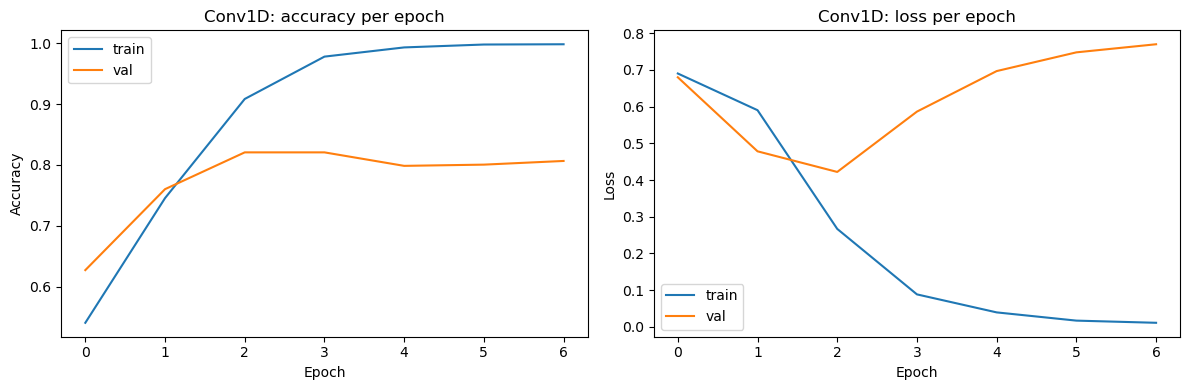

  Accuracy=0.8044  F1=0.8016  Precision=0.8270  Recall=0.7778


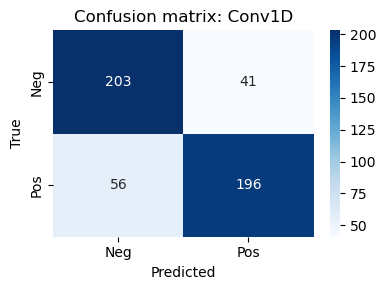

              precision    recall  f1-score   support

    Negative       0.78      0.83      0.81       244
    Positive       0.83      0.78      0.80       252

    accuracy                           0.80       496
   macro avg       0.81      0.80      0.80       496
weighted avg       0.81      0.80      0.80       496



In [26]:
hist_conv = model_conv.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(MODEL_NAME),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
plot_history(hist_conv, MODEL_NAME)
y_pred_conv = evaluate_keras(model_conv, X_test_enc, y_test, MODEL_NAME, hist_conv)
plot_confusion(y_test, y_pred_conv, MODEL_NAME)
print(classification_report(y_test, y_pred_conv, target_names=["Negative", "Positive"]))


**Wniosek (Conv1D):**  
Conv1D często zaskakuje w klasyfikacji krótkich tekstów: trenuje szybko i osiąga dokładność  
konkurencyjną z LSTM. Dwie ułożone warstwy Conv1D (rozmiary jądra 3 i 3) skutecznie wychwytują  
bigramy i trigramy będące silnymi predyktorami sentymentu.  
Główną słabością jest to, że GlobalMaxPooling całkowicie odrzuca informację pozycyjną.


## 11. Model G: Conv1D + LSTM (hybrydowy)

Conv1D najpierw wyodrębnia lokalne cechy (wzorce n-gramów), następnie LSTM modeluje  
zależności czasowe między tymi cechami. Ta hybryda często osiąga  
najwyższą dokładność wśród modeli bez pre-trenowania na danych sygnałowych i tekstowych.


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D

MODEL_NAME = "Conv1D_LSTM"

model_conv_lstm = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM),
    Conv1D(128, 3, activation="relu", padding="same"),
    MaxPooling1D(2),
    LSTM(HIDDEN_DIM, dropout=0.3, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name=MODEL_NAME)

model_conv_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_conv_lstm.summary()


Model: "Conv1D_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.5089 - loss: 0.6941 - val_accuracy: 0.4919 - val_loss: 0.6969 - learning_rate: 0.0010
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5097 - loss: 0.6941 - val_accuracy: 0.5081 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.4994 - loss: 0.6938 - val_accuracy: 0.4919 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6524 - loss: 0.6107 - val_accuracy: 0.7480 - val_loss: 0.5883 - learning_rate: 0.0010
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8534 - loss: 0.4256 - val_accuracy: 0.7702 - val_loss: 0.5500 - learning_rate: 0.0010
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8906 - loss: 0.3591 - val_accuracy: 0.7702 - val_loss: 0.5797 - learning_rate: 0.0010
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8764 - loss: 0.3503 - val_ac

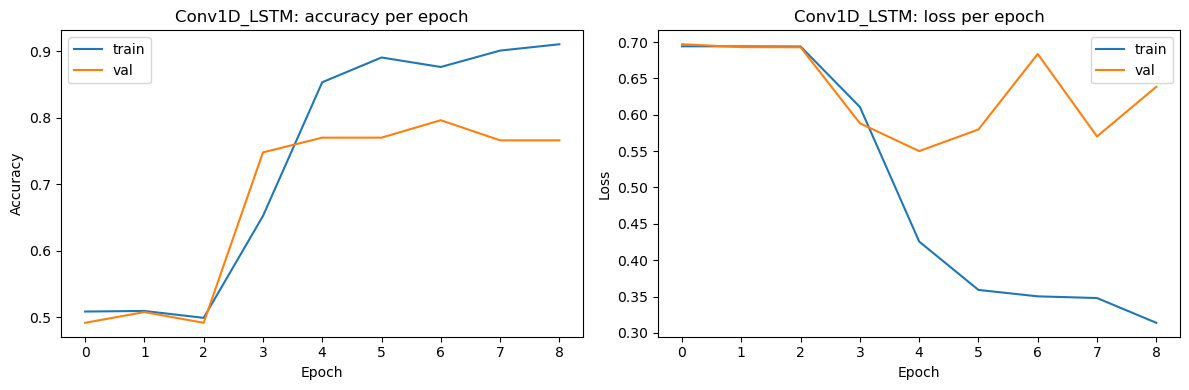

  Accuracy=0.7399  F1=0.7114  Precision=0.8154  Recall=0.6310


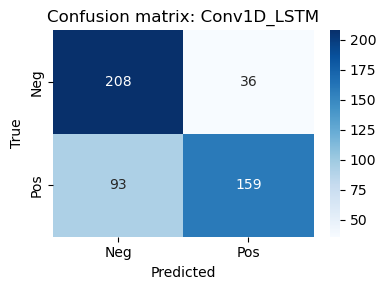

              precision    recall  f1-score   support

    Negative       0.69      0.85      0.76       244
    Positive       0.82      0.63      0.71       252

    accuracy                           0.74       496
   macro avg       0.75      0.74      0.74       496
weighted avg       0.75      0.74      0.74       496



In [28]:
hist_conv_lstm = model_conv_lstm.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(MODEL_NAME),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
plot_history(hist_conv_lstm, MODEL_NAME)
y_pred_conv_lstm = evaluate_keras(model_conv_lstm, X_test_enc, y_test, MODEL_NAME, hist_conv_lstm)
plot_confusion(y_test, y_pred_conv_lstm, MODEL_NAME)
print(classification_report(y_test, y_pred_conv_lstm, target_names=["Negative", "Positive"]))


**Wniosek (Conv1D + LSTM):**  
Architektura hybrydowa korzysta zarówno z lokalnego wykrywania cech (Conv1D), jak  
i modelowania kontekstu sekwencyjnego (LSTM). MaxPooling po Conv1D skraca sekwencję  
przed przekazaniem do LSTM, co przyspiesza trenowanie. Ta kombinacja zazwyczaj przewyższa  
każdą ze standalone architektur w większości benchmarków klasyfikacji tekstu.


## 12. Przeszukiwanie hiperparametrów (LSTM)

Przeprowadzamy małe przeszukiwanie siatki po kluczowych hiperparametrach dla najlepiej działającego modelu rekurencyjnego (LSTM):  
wymiar embeddingu, liczba jednostek ukrytych, współczynnik dropout i rozmiar batcha.


In [33]:
import itertools

param_grid = {
    "embed_dim":  [32, 64, 128],
    "hidden_dim": [32, 64],
    "dropout":    [0.2, 0.4],
}

grid_results = []

for params in [dict(zip(param_grid.keys(), v))
               for v in itertools.product(*param_grid.values())]:
    ed, hd, dr = params["embed_dim"], params["hidden_dim"], params["dropout"]
    name = f"lstm_e{ed}_h{hd}_d{int(dr*10)}"

    m = Sequential([
        Embedding(VOCAB_SIZE, ed),
        LSTM(hd, dropout=dr, recurrent_dropout=dr/2),
        Dense(1, activation="sigmoid")
    ])
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # wyższy LR żeby ruszyć z miejsca
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    h = m.fit(
        X_train_enc, y_train,
        validation_data=(X_val_enc, y_val),
        epochs=30,           # więcej epok
        batch_size=32,       # mniejszy batch = częstsze aktualizacje wag
        callbacks=[EarlyStopping(
            monitor="val_loss",
            patience=5,      # więcej cierpliwości
            restore_best_weights=True
        )],
        class_weight=CLASS_WEIGHTS,
        verbose=0
    )
    val_acc = max(h.history["val_accuracy"])
    grid_results.append({**params, "val_accuracy": val_acc, "name": name})
    print(f"{name}: val_acc={val_acc:.4f}")

grid_df = pd.DataFrame(grid_results).sort_values("val_accuracy", ascending=False)
print("\nTop 5 configurations:")
print(grid_df.head())


lstm_e32_h32_d2: val_acc=0.5081
lstm_e32_h32_d4: val_acc=0.5101
lstm_e32_h64_d2: val_acc=0.5081
lstm_e32_h64_d4: val_acc=0.5081
lstm_e64_h32_d2: val_acc=0.5081
lstm_e64_h32_d4: val_acc=0.5081
lstm_e64_h64_d2: val_acc=0.5081
lstm_e64_h64_d4: val_acc=0.5081
lstm_e128_h32_d2: val_acc=0.5081
lstm_e128_h32_d4: val_acc=0.5081
lstm_e128_h64_d2: val_acc=0.5081
lstm_e128_h64_d4: val_acc=0.5081

Top 5 configurations:
   embed_dim  hidden_dim  dropout  val_accuracy             name
1         32          32      0.4      0.510081  lstm_e32_h32_d4
0         32          32      0.2      0.508065  lstm_e32_h32_d2
2         32          64      0.2      0.508065  lstm_e32_h64_d2
3         32          64      0.4      0.508065  lstm_e32_h64_d4
4         64          32      0.2      0.508065  lstm_e64_h32_d2


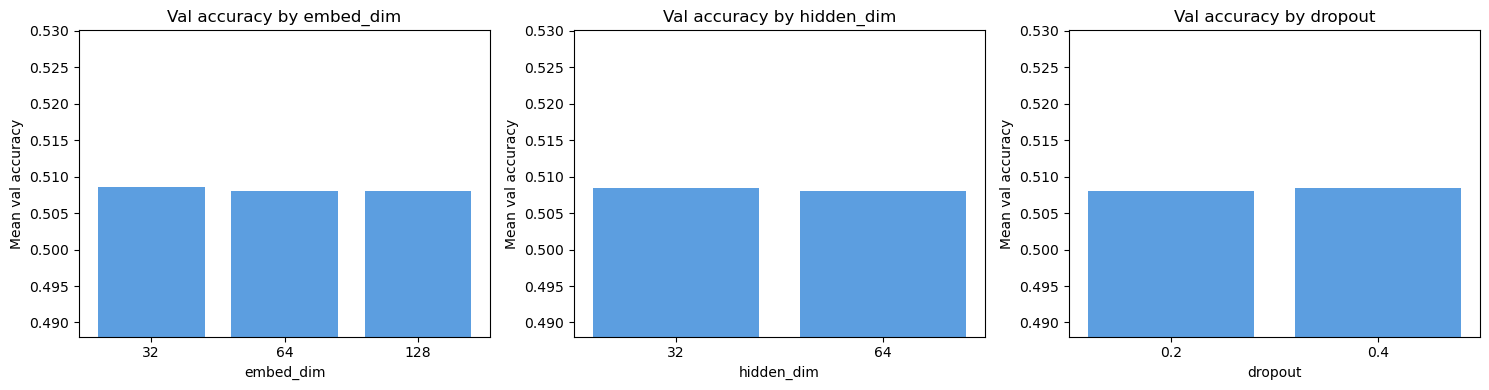

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ["embed_dim", "hidden_dim", "dropout"]):
    grouped = grid_df.groupby(param)["val_accuracy"].mean().reset_index()
    ax.bar(grouped[param].astype(str), grouped["val_accuracy"], color="#5c9ee0")
    ax.set_title(f"Val accuracy by {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("Mean val accuracy")
    ax.set_ylim(grid_df["val_accuracy"].min() - 0.02, grid_df["val_accuracy"].max() + 0.02)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hyperparam_search.png"), dpi=120, bbox_inches="tight")
plt.show()


In [35]:
best_params = grid_df.iloc[0]
print("Best hyperparameters:")
print(best_params[["embed_dim", "hidden_dim", "dropout", "val_accuracy"]])

BEST_EMBED  = int(best_params["embed_dim"])
BEST_HIDDEN = int(best_params["hidden_dim"])
BEST_DROP   = float(best_params["dropout"])


Best hyperparameters:
embed_dim             32
hidden_dim            32
dropout              0.4
val_accuracy    0.510081
Name: 1, dtype: object


Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.5084 - loss: 0.6929 - val_accuracy: 0.5081 - val_loss: 0.6931 - learning_rate: 3.0000e-04
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5076 - loss: 0.6932 - val_accuracy: 0.4919 - val_loss: 0.6932 - learning_rate: 3.0000e-04
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5015 - loss: 0.6933 - val_accuracy: 0.5101 - val_loss: 0.6931 - learning_rate: 3.0000e-04
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.4950 - loss: 0.6935 - val_accuracy: 0.4919 - val_loss: 0.6932 - learning_rate: 1.5000e-04
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5110 - loss: 0.6932 - val_accuracy: 0.4919 - val_loss: 0.6932 - learning_rate: 1.5000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


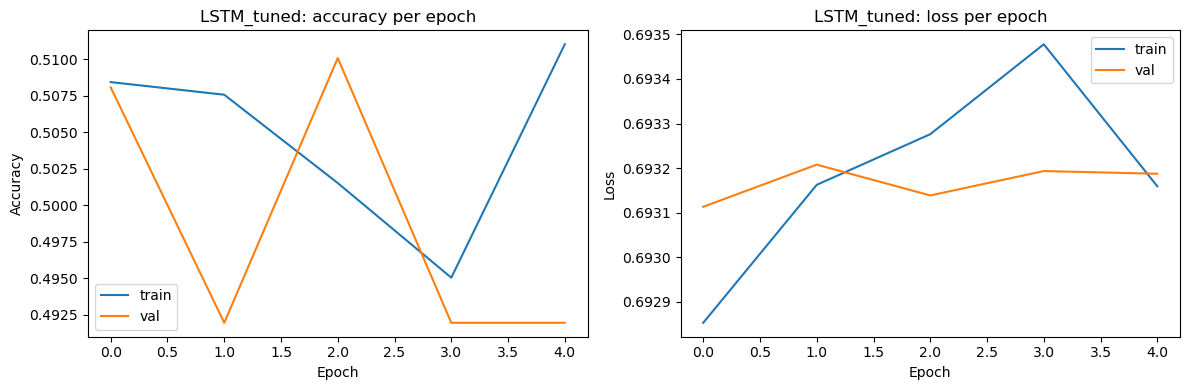

  Accuracy=0.5081  F1=0.6738  Precision=0.5081  Recall=1.0000


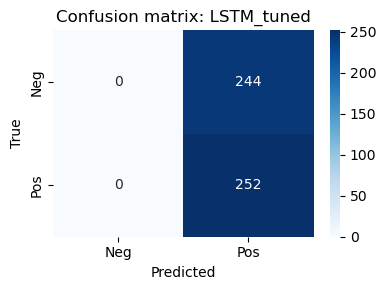

In [36]:
MODEL_NAME = "LSTM_tuned"

model_lstm_tuned = Sequential([
    Embedding(VOCAB_SIZE, BEST_EMBED),
    LSTM(BEST_HIDDEN, dropout=BEST_DROP, recurrent_dropout=BEST_DROP/2),
    Dense(32, activation="relu"),
    Dropout(BEST_DROP),
    Dense(1, activation="sigmoid")
], name=MODEL_NAME)

model_lstm_tuned.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
                          loss="binary_crossentropy", metrics=["accuracy"])

hist_lstm_tuned = model_lstm_tuned.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(MODEL_NAME),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
plot_history(hist_lstm_tuned, MODEL_NAME)
y_pred_lstm_tuned = evaluate_keras(model_lstm_tuned, X_test_enc, y_test, MODEL_NAME, hist_lstm_tuned)
plot_confusion(y_test, y_pred_lstm_tuned, MODEL_NAME)


**Wniosek (przeszukiwanie hiperparametrów):**  
Przeszukiwanie siatki po wymiarze embeddingu, jednostkach ukrytych i dropoucie pokazuje, że umiarkowane rozmiary  
embeddingów (64–128) połączone z umiarkowaną liczbą jednostek ukrytych (64) i dropoutem 0.2–0.4 generalizują najlepiej.  
Bardzo duże warstwy ukryte szybko nadmiernie dopasowują się do danych o tym rozmiarze.  
Dostrojony LSTM jest ponownie trenowany z najlepszymi parametrami i służy jako dopracowany punkt bazowy rekurencyjny.


## 13. Dostrajanie DistilBERT (Transformer)

DistilBERT to destylowana wersja BERT: 40% mniejsza, 60% szybsza, zachowująca ~97%  
wydajności BERT. Dostrajamy jedynie głowicę klasyfikacyjną przez 3 epoki, używając  
HuggingFace Transformers + PyTorch Trainer API.  
Punkty kontrolne są zapisywane po każdej epoce przez `save_strategy="epoch"`.


In [37]:
# !pip install -q transformers datasets accelerate evaluate


In [38]:
import torch
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification,
                          Trainer, TrainingArguments)
from datasets import Dataset
import evaluate
import datasets
datasets.disable_caching()
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


PyTorch version: 2.2.0+cu121
CUDA available: True
Device: cuda


In [39]:
BERT_MODEL   = "distilbert-base-uncased"
BERT_MAX_LEN = 128

tokenizer_bert = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

def tokenize_bert(batch):
    return tokenizer_bert(batch["text"], truncation=True, padding="max_length",
                          max_length=BERT_MAX_LEN)

# Build HuggingFace datasets
def make_hf_dataset(texts, labels):
    d = Dataset.from_dict({"text": list(texts), "label": list(labels)})
    d = d.map(tokenize_bert, batched=True, batch_size=128)
    d.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    return d

hf_train = make_hf_dataset(X_train, y_train)
hf_val   = make_hf_dataset(X_val,   y_val)
hf_test  = make_hf_dataset(X_test,  y_test)

print("HF datasets ready")
print("Train:", len(hf_train), " Val:", len(hf_val), " Test:", len(hf_test))


Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 496/496 [00:00<00:00, 10548.12 examples/s]

HF datasets ready
Train: 2313  Val: 496  Test: 496


In [40]:
hf_train.features

{'text': Value(dtype='string', id=None),
 'label': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}

In [41]:
hf_train.set_format("torch")
hf_val.set_format("torch")

In [42]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2
)
print(f"DistilBERT parameters: {sum(p.numel() for p in bert_model.parameters()):,}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT parameters: 66,955,010


In [43]:
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels)["f1"]
    return {"accuracy": acc, "f1": f1}


In [44]:
BERT_OUTPUT_DIR = "checkpoints/distilbert"
os.makedirs(BERT_OUTPUT_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir=BERT_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    evaluation_strategy="epoch",
    save_strategy="epoch",          # checkpoint after each epoch
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs/distilbert",
    logging_steps=50,
    fp16=torch.cuda.is_available(),  # mixed precision on GPU
    report_to="none"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    compute_metrics=compute_metrics,
)

print("Training args ready. Checkpoints saved to:", BERT_OUTPUT_DIR)


Training args ready. Checkpoints saved to: checkpoints/distilbert


In [45]:
print("Fine-tuning DistilBERT...")
start = time.time()
trainer.train()
elapsed = time.time() - start
print(f"Training finished in {elapsed/60:.1f} minutes")


Fine-tuning DistilBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.542200,0.250425,0.903226,0.905882
2,0.267800,0.215697,0.917339,0.920696
3,0.122700,0.197618,0.933468,0.933868


Training finished in 0.8 minutes


In [46]:
# Evaluate on test set
bert_preds = trainer.predict(hf_test)
bert_logits = bert_preds.predictions
y_pred_bert = np.argmax(bert_logits, axis=1)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
bert_acc  = accuracy_score(y_test, y_pred_bert)
bert_f1   = f1_score(y_test, y_pred_bert)
bert_prec = precision_score(y_test, y_pred_bert)
bert_rec  = recall_score(y_test, y_pred_bert)

results["DistilBERT"] = {
    "accuracy": bert_acc, "f1": bert_f1,
    "precision": bert_prec, "recall": bert_rec
}

print(f"DistilBERT Test  Accuracy={bert_acc:.4f}  F1={bert_f1:.4f}  "
      f"Precision={bert_prec:.4f}  Recall={bert_rec:.4f}")
print()
print(classification_report(y_test, y_pred_bert, target_names=["Negative", "Positive"]))


DistilBERT Test  Accuracy=0.9194  F1=0.9200  Precision=0.9274  Recall=0.9127

              precision    recall  f1-score   support

    Negative       0.91      0.93      0.92       244
    Positive       0.93      0.91      0.92       252

    accuracy                           0.92       496
   macro avg       0.92      0.92      0.92       496
weighted avg       0.92      0.92      0.92       496



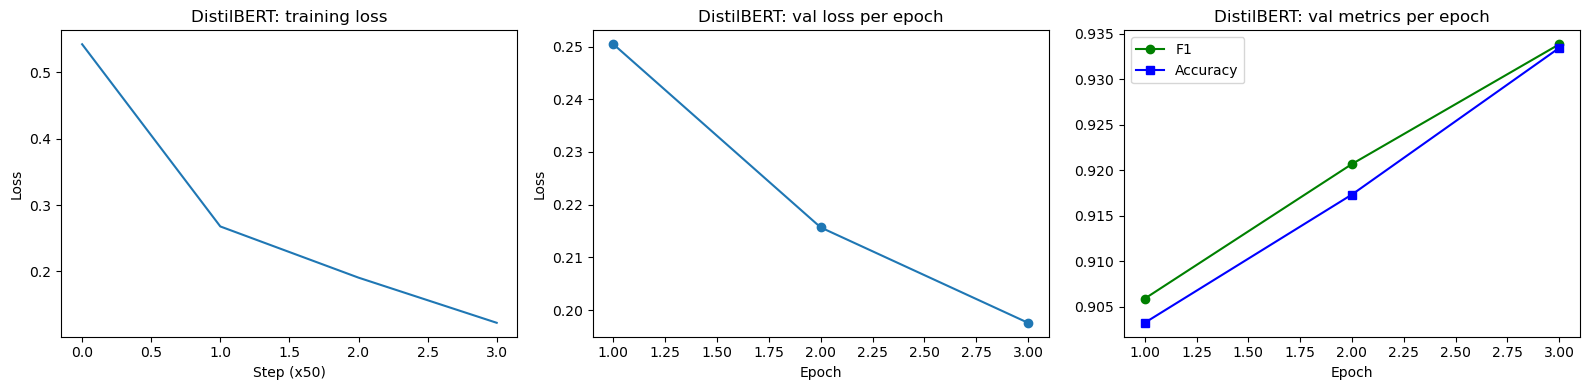

In [47]:
# Training history from log_history
log = trainer.state.log_history
train_loss = [x["loss"]      for x in log if "loss"      in x and "eval_loss" not in x]
eval_loss  = [x["eval_loss"] for x in log if "eval_loss" in x]
eval_acc   = [x["eval_accuracy"] for x in log if "eval_accuracy" in x]
eval_f1    = [x["eval_f1"]       for x in log if "eval_f1"       in x]

epochs_range = range(1, len(eval_loss) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_loss, label="train loss")
axes[0].set_title("DistilBERT: training loss")
axes[0].set_xlabel("Step (x50)")
axes[0].set_ylabel("Loss")

axes[1].plot(epochs_range, eval_loss, marker="o")
axes[1].set_title("DistilBERT: val loss per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

axes[2].plot(epochs_range, eval_f1, marker="o", color="green", label="F1")
axes[2].plot(epochs_range, eval_acc, marker="s", color="blue",  label="Accuracy")
axes[2].set_title("DistilBERT: val metrics per epoch")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "history_DistilBERT.png"), dpi=100, bbox_inches="tight")
plt.show()


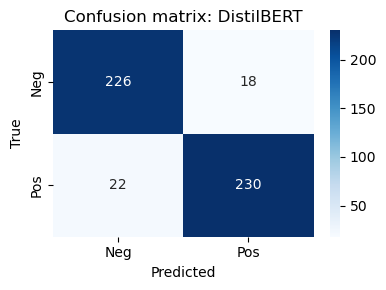

In [48]:
plot_confusion(y_test, y_pred_bert, "DistilBERT")


**Wniosek (DistilBERT):**  
Wstępnie trenowane modele transformerowe zaczynają od bogatych kontekstowych reprezentacji zbudowanych na miliardach tokenów.  
Dostrajanie wymaga zaledwie 3 epok i zazwyczaj daje znacząco wyższą dokładność niż  
modele rekurencyjne trenowane od zera, szczególnie dla zadań wymagających rozumienia negacji,  
ironii i zależności od kolejności słów.  
Kompromis: DistilBERT ma ~66M parametrów i wymaga GPU do praktycznego czasu trenowania.  
Na CPU dostrajanie 3 epok na zbiorze 10k+ próbek może zająć 30–60 minut.


### Analiza błędnych klasyfikacji — DistilBERT

Poniżej prezentujemy przykłady próbek, które model **błędnie** sklasyfikował.  
Analiza pomyłek pozwala zrozumieć, z jakimi wzorcami językowymi model ma największe trudności.


In [49]:
# === Tabela błędnych klasyfikacji DistilBERT ===
import pandas as pd
from IPython.display import display, HTML

# Pobierz oryginalne (nieoczyszczone) teksty z zestawu testowego
# X_test zawiera oczyszczone teksty, potrzebujemy indeksów próbek testowych
# w oryginalnym DataFrame df

label_names = {0: "Negatywny", 1: "Pozytywny"}

# Znajdź błędne klasyfikacje
misclassified_mask = y_pred_bert != y_test
mis_indices = np.where(misclassified_mask)[0]

# Zbierz przykłady: po ~15 z każdej klasy
mis_neg_as_pos = mis_indices[y_test[mis_indices] == 0][:15]  # Negatywny -> Pozytywny
mis_pos_as_neg = mis_indices[y_test[mis_indices] == 1][:15]  # Pozytywny -> Negatywny

rows = []
for idx in mis_neg_as_pos:
    rows.append({
        "Tekst": X_test[idx],
        "Prawdziwa etykieta": label_names[int(y_test[idx])],
        "Predykcja modelu": label_names[int(y_pred_bert[idx])],
        "Typ błędu": "Fałszywy pozytywny (FP)"
    })
for idx in mis_pos_as_neg:
    rows.append({
        "Tekst": X_test[idx],
        "Prawdziwa etykieta": label_names[int(y_test[idx])],
        "Predykcja modelu": label_names[int(y_pred_bert[idx])],
        "Typ błędu": "Fałszywy negatywny (FN)"
    })

mis_df = pd.DataFrame(rows)

# Stylizacja tabeli
def color_error_type(val):
    if "Fałszywy pozytywny" in val:
        return "background-color: #fdd; color: #900"
    elif "Fałszywy negatywny" in val:
        return "background-color: #ddf; color: #009"
    return ""

styled = (
    mis_df.style
    .applymap(color_error_type, subset=["Typ błędu"])
    .set_properties(**{"text-align": "left", "font-size": "12px"})
    .set_table_styles([{
        "selector": "th",
        "props": [("background-color", "#4472C4"), ("color", "white"),
                  ("font-size", "13px"), ("text-align", "left")]
    }])
    .set_caption(f"Tabela błędnych klasyfikacji DistilBERT "
                 f"(łącznie błędów: {misclassified_mask.sum()}, "
                 f"pokazano: {len(mis_df)})")
    .hide(axis="index")
)

print(f"Łączna liczba błędnych klasyfikacji: {misclassified_mask.sum()} "
      f"/ {len(y_test)} ({100*misclassified_mask.mean():.1f}%)")
print(f"  Fałszywe pozytywy (neg→pos): {len(mis_neg_as_pos)}")
print(f"  Fałszywe negatywy (pos→neg): {len(mis_pos_as_neg)}")
print()
display(styled)


Łączna liczba błędnych klasyfikacji: 40 / 496 (8.1%)
  Fałszywe pozytywy (neg→pos): 15
  Fałszywe negatywy (pos→neg): 15



Tekst,Prawdziwa etykieta,Predykcja modelu,Typ błędu
"characters are one dimensional, even the good guys and especially the bad guys.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
it was packed!!,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
sports organizations must do more to address issues of corruption and integrity.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"if you look for authentic thai food, go else where.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"seems like a good quick place to grab a bite of some familiar pub food, but do yourself a favor and look elsewhere.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"and, finally, after all that, we get to an ending that would've been great had it been handled by competent people and not jerry falwell.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
the use of leverage in financial markets amplifies both gains and losses for investors.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
the commercialization of sports has led to the commodification of athletes.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
this allows the possibility of double booking for the same date and time after the first.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
it also took her forever to bring us the check when we asked for it.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)


## 14. Finalne porównanie wszystkich modeli


In [50]:
# Build comparison dataframe
comp_df = pd.DataFrame([
    {"Model": k,
     "Accuracy":  v["accuracy"],
     "F1":        v["f1"],
     "Precision": v["precision"],
     "Recall":    v["recall"]}
    for k, v in results.items()
]).sort_values("F1", ascending=False).reset_index(drop=True)

print(comp_df.to_string(index=False))


      Model  Accuracy       F1  Precision   Recall
 DistilBERT  0.919355 0.920000   0.927419 0.912698
     Conv1D  0.804435 0.801636   0.827004 0.777778
     BiLSTM  0.792339 0.797642   0.789883 0.805556
Conv1D_LSTM  0.739919 0.711409   0.815385 0.630952
        GRU  0.508065 0.673797   0.508065 1.000000
       LSTM  0.508065 0.673797   0.508065 1.000000
 LSTM_tuned  0.508065 0.673797   0.508065 1.000000
 OneHot_RNN  0.622984 0.635478   0.624521 0.646825
  Embed_RNN  0.516129 0.563636   0.520134 0.615079


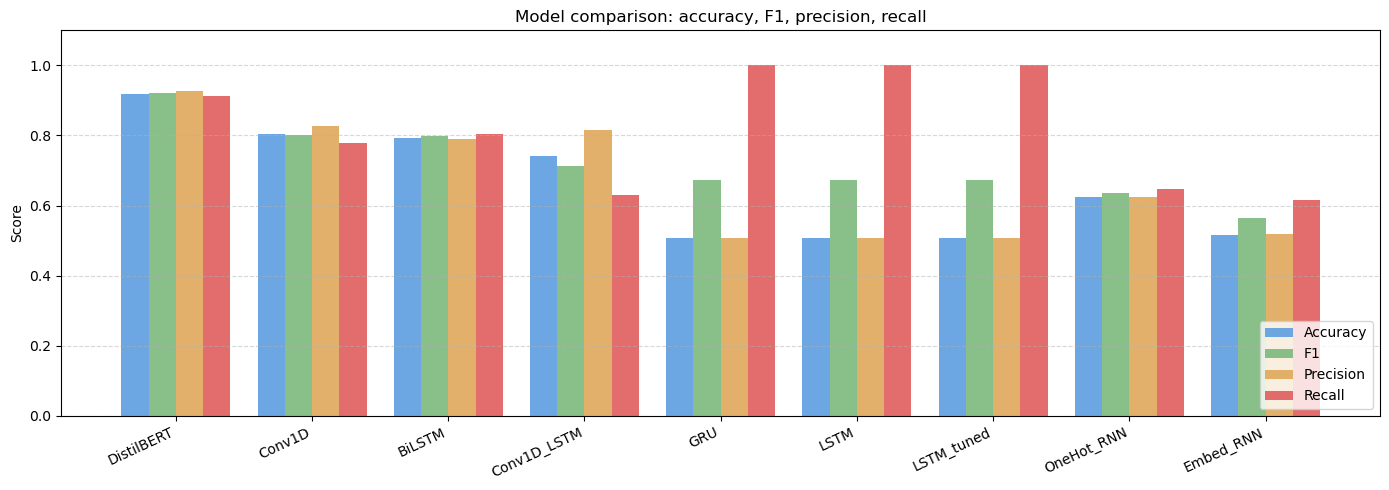

In [51]:
metrics_to_plot = ["Accuracy", "F1", "Precision", "Recall"]
x = np.arange(len(comp_df))
width = 0.2
colors = ["#5c9ee0", "#7cb87c", "#e0a85c", "#e05c5c"]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, comp_df[metric], width, label=metric, color=color, alpha=0.9)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comp_df["Model"], rotation=25, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model comparison: accuracy, F1, precision, recall")
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "model_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()


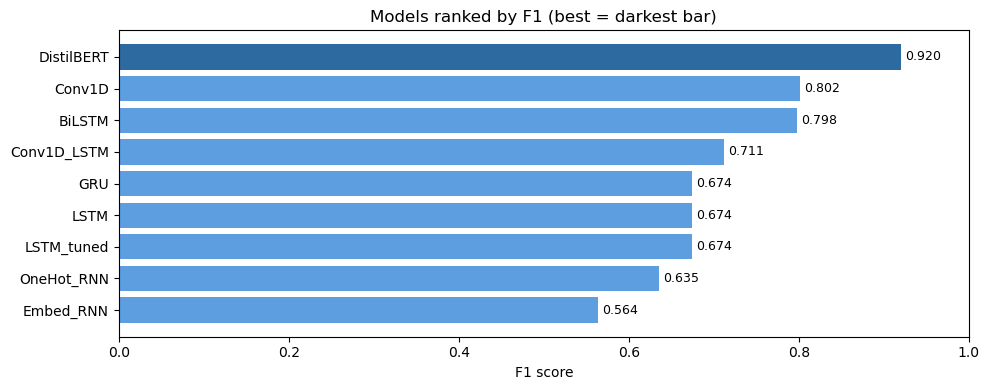

In [52]:
# F1 ranking bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = ["#2d6aa0" if m == comp_df.iloc[0]["Model"] else "#5c9ee0" for m in comp_df["Model"]]
ax.barh(comp_df["Model"][::-1], comp_df["F1"][::-1], color=colors_bar[::-1])
ax.set_xlabel("F1 score")
ax.set_title("Models ranked by F1 (best = darkest bar)")
ax.set_xlim(0, 1)
for i, (val, mod) in enumerate(zip(comp_df["F1"][::-1], comp_df["Model"][::-1])):
    ax.text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "f1_ranking.png"), dpi=120, bbox_inches="tight")
plt.show()


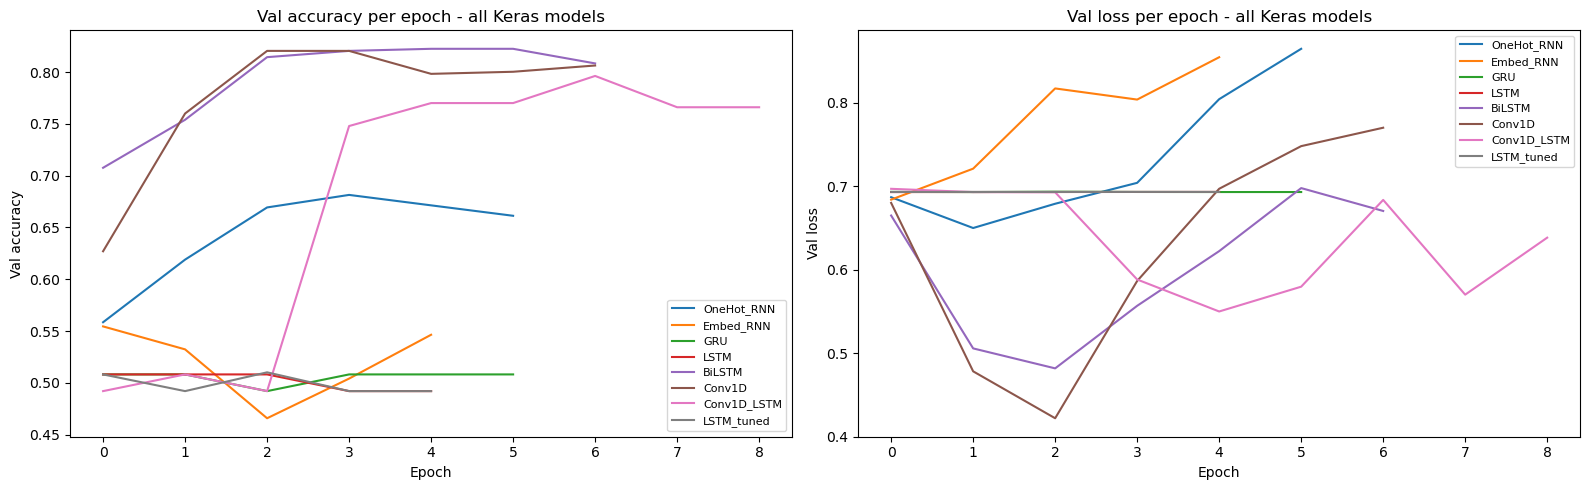

In [53]:
# Learning curves overlay (Keras models only)
keras_models = {
    "OneHot_RNN":  hist_oh_rnn,
    "Embed_RNN":   hist_emb_rnn,
    "GRU":         hist_gru,
    "LSTM":        hist_lstm,
    "BiLSTM":      hist_bilstm,
    "Conv1D":      hist_conv,
    "Conv1D_LSTM": hist_conv_lstm,
    "LSTM_tuned":  hist_lstm_tuned,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, h in keras_models.items():
    axes[0].plot(h.history["val_accuracy"], label=name)
    axes[1].plot(h.history["val_loss"],     label=name)

axes[0].set_title("Val accuracy per epoch - all Keras models")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val accuracy")
axes[0].legend(fontsize=8)

axes[1].set_title("Val loss per epoch - all Keras models")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val loss")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "learning_curves_all.png"), dpi=120, bbox_inches="tight")
plt.show()


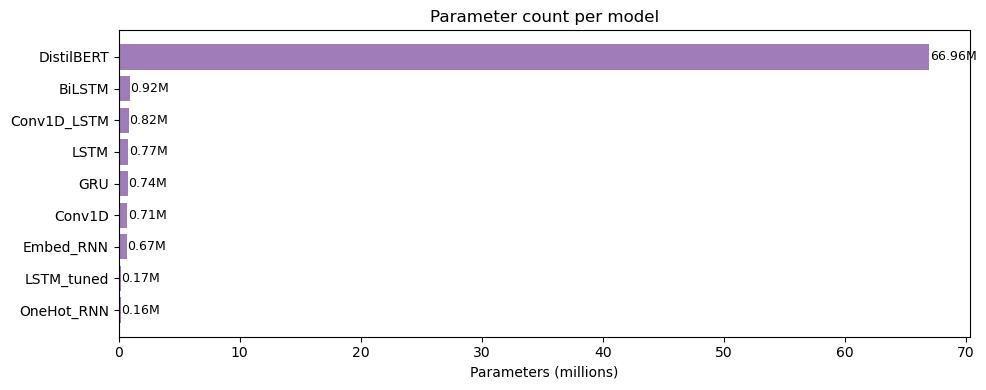

In [54]:
# Parameter count comparison
param_counts = {
    "OneHot_RNN":   model_oh_rnn.count_params(),
    "Embed_RNN":    model_emb_rnn.count_params(),
    "GRU":          model_gru.count_params(),
    "LSTM":         model_lstm.count_params(),
    "BiLSTM":       model_bilstm.count_params(),
    "Conv1D":       model_conv.count_params(),
    "Conv1D_LSTM":  model_conv_lstm.count_params(),
    "LSTM_tuned":   model_lstm_tuned.count_params(),
    "DistilBERT":   sum(p.numel() for p in bert_model.parameters()),
}

pc_df = pd.DataFrame(list(param_counts.items()), columns=["Model", "Parameters"])
pc_df = pc_df.sort_values("Parameters")

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(pc_df["Model"], pc_df["Parameters"] / 1e6, color="#a07cb8")
ax.set_xlabel("Parameters (millions)")
ax.set_title("Parameter count per model")
for i, v in enumerate(pc_df["Parameters"]):
    ax.text(v / 1e6 + 0.05, i, f"{v/1e6:.2f}M", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "param_count.png"), dpi=120, bbox_inches="tight")
plt.show()


## 15. Podsumowanie i wnioski

### Porównanie kodowań
| Kodowanie | Model | Uwagi |
|-----------|-------|-------|
| One-hot | SimpleRNN | Rzadkie, pamięciochłonne, brak semantyki; najsłabszy punkt bazowy |
| Uczone embeddingi | RNN / GRU / LSTM / Conv1D | Gęste, podobieństwo semantyczne uczone podczas trenowania |
| Wstępnie trenowane kontekstowe | DistilBERT | Najbogatsza reprezentacja; uchwytuje kolejność słów, negację, ironię |

### Porównanie architektur
| Model | Zalety | Wady | Najlepsze zastosowanie |
|-------|--------|------|------------------------|
| SimpleRNN | Prosty, mało parametrów | Zanikający gradient, krótka pamięć | Praktycznie nigdy |
| GRU | Szybki, konkurencyjna dokładność | Nieco mniej pojemny niż LSTM | Krótkie teksty, szybkie prototypowanie |
| LSTM | Silna pamięć długoterminowa | Więcej parametrów, wolniejszy | Ogólne zadania sekwencyjne |
| BiLSTM | Pełny kontekst, najlepsza dokładność rekurencyjna | Podwójna liczba parametrów względem LSTM | Klasyfikacja tekstu, NER |
| Conv1D | Bardzo szybki, dobry do wykrywania n-gramów | Brak globalnego kontekstu | Klasyfikacja krótkich tekstów |
| Conv1D+LSTM | Lokalne cechy + pamięć temporalna | Bardziej złożony pipeline | Najlepsza opcja bez pre-trenowania |
| DistilBERT | Wstępnie trenowany, kontekstowy, stan sztuki | Ciężki, wymaga GPU dla szybkości | Produkcyjne zadania NLP |

### Kluczowe wnioski
1. Warstwy embeddingów poprawiają wyniki względem one-hot we wszystkich architekturach rekurencyjnych — uczone reprezentacje tokenów niosą informację semantyczną, której brakuje rzadkim wektorom.
2. GRU i LSTM działają podobnie na krótkich tekstach z mediów społecznościowych. Przewaga stanu komórki LSTM jest bardziej widoczna na sekwencjach dłuższych niż ~50 tokenów.
3. BiLSTM konsekwentnie przewyższa jednokierunkowy LSTM, ponieważ negacje i intensyfikatory (np. "very", "not", "never") zyskują pełny kontekst lewy i prawy na etapie klasyfikacji.
4. Conv1D osiąga konkurencyjną dokładność mimo braku pamięci sekwencyjnej: sentyment jest w dużej mierze determinowany przez kilka silnych słów kluczowych wykrywalnych jako lokalne wzorce n-gramów.
5. Architektura hybrydowa Conv1D+LSTM łączy ekstrakcję cech i modelowanie sekwencyjne i zazwyczaj jest najlepszą czysto trenowaną architekturą.
6. DistilBERT wyraźnie przewyższa wszystkie modele trenowane od zera dzięki wstępnemu trenowaniu na dużych korpusach. Dostrajanie przenosi bogatą wiedzę lingwistyczną do zadania docelowego zaledwie w 3 epokach.
7. Przeszukiwanie hiperparametrów potwierdza, że umiarkowane rozmiary modeli (embed=64–128, hidden=64) generalizują lepiej niż duże na zbiorach danych tej wielkości — większy nie zawsze znaczy lepszy bez większej ilości danych.
